**CS 301-002**

**Final Project**

Saahil Dhabalia,
Emilie Inzinna-Enriquez,
Ruben Carmona

# Data Preperation and Cleaning

These are the original datasets we used for this project:

Chicago socioeconomic indicators
*   https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2/about_data

List of metro stations in Chicago and location
*   https://data.cityofchicago.org/Transportation/CTA-System-Information-List-of-L-Stops/8pix-ypme

List of metro stations in Chicago and daily ridership
*   https://data.cityofchicago.org/Transportation/CTA-Ridership-L-Station-Entries-Daily-Totals/5neh-572f/about_data

We had to make some major modifications to the datasets to get them to work as intended.
For CTA Ridership Daily Total, we removed all dates not from the 2008-2012 range.
* Reason 1: The dataset was just too massive
* Reason 2: It better lines up with the Socioeconomic Factors dataset now, as that dataset is from 2008 - 2012

Then we used the Station ID column from the two CTA datasets to aggregate them into one set for simplicty. This new set is "Aggregated_CTA_Transit_Stations", and contains Stop ID, Average Daily Rides, and Coordinates.

Next, we had to tie the coordinates from the CTA set to the locations in the Socioeconomic Indicators set. This required us to use a Point-in-Point Spatial Join and geopandas.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm

In [ ]:
# Load Datasets
transit_df = pd.read_csv('Aggregated_CTA_Transit_Stations.csv')
socio_df = pd.read_csv('Socioeconomic_Indicators_In_Chicago.csv')

# Convert transit data into a spatial Geoframe
geometry = [Point(xy) for xy in zip(transit_df['Longitude'], transit_df['Latitude'])]
transit_gdf = gpd.GeoDataFrame(transit_df, crs="EPSG:4326", geometry=geometry)

# Read the Chicago community areas geoJSON
community_areas_gdf = gpd.read_file('chicago_community_areas.geojson')

# Make sure both maps use the same coordinate system
community_areas_gdf = community_areas_gdf.to_crs(transit_gdf.crs)

# Spatial Join
stations_in_neighborhoods = gpd.sjoin(transit_gdf, community_areas_gdf, how="inner", predicate="within")

# Aggregate transit data by community area
neighborhood_transit = stations_in_neighborhoods.groupby('area_numbe').agg( # The json has 'area_numbe' for some reason
    Total_Stations=('station_id', 'count'),
    Total_Avg_Daily_Rides=('avg_daily_rides', 'sum')
).reset_index()

neighborhood_transit['area_numbe'] = neighborhood_transit['area_numbe'].astype(float)

# Merge into the final dataframe
df = pd.merge(
    socio_df,
    neighborhood_transit,
    left_on='Community Area Number',
    right_on='area_numbe',
    how='left')

# Fill neighborhoods with 0 transit access with 0s instead of NaNs
df['Total_Stations'] = df['Total_Stations'].fillna(0)
df['Total_Avg_Daily_Rides'] = df['Total_Avg_Daily_Rides'].fillna(0)



In [ ]:
# Check the dataframe
df = df.drop(columns=['area_numbe', 'Community Area Number'])
df

,COMMUNITY AREA NAME,PERCENT OF HOUSING CROWDED,PERCENT HOUSEHOLDS BELOW POVERTY,PERCENT AGED 16+ UNEMPLOYED,PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA,PERCENT AGED UNDER 18 OR OVER 64,PER CAPITA INCOME,HARDSHIP INDEX,Total_Stations,Total_Avg_Daily_Rides
0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0,4.0,15273.636835
1,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0,0.0,0.000000
2,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0,3.0,10484.341487
3,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0,4.0,8330.121126
4,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0,2.0,3884.023382
...,...,...,...,...,...,...,...,...,...,...
73,Mount Greenwood,1.0,3.4,8.7,4.3,36.8,34381,16.0,0.0,0.000000
74,Morgan Park,0.8,13.2,15.0,10.8,40.3,27149,30.0,0.0,0.000000
75,O'Hare,3.6,15.4,7.1,10.9,30.3,25828,24.0,2.0,12646.767062
76,Edgewater,4.1,18.2,9.2,9.7,23.8,33385,19.0,4.0,12790.613245


# Exploratory Data Analysis

In [ ]:
# We have a neighborhood count of 78
print(f"Neighborhood Count: {len(df)}")

Neighborhood Count: 78


**Feature Distributions**

Text(0.5, 1.0, 'Distribution of Unemployment Rate')

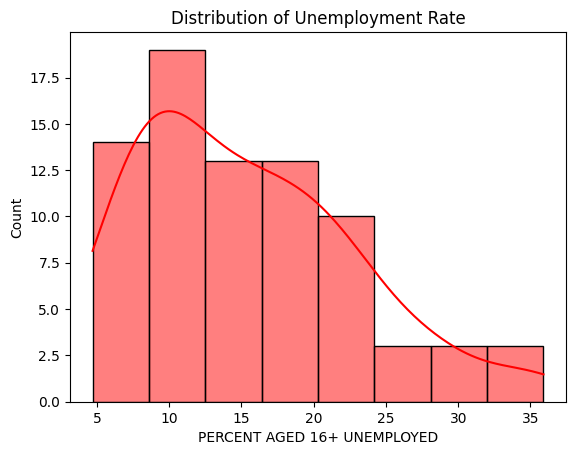

In [ ]:
# Unemployment Rate is the target variable
sns.histplot(df['PERCENT AGED 16+ UNEMPLOYED'], kde=True, color='red')
plt.title('Distribution of Unemployment Rate')

We see a fair right-skew in this graph, showing that most neighborhoods have an unemplyment rate of 20% or less, with only a few neighborhoods having a higher rate.

Text(0.5, 1.0, 'Distribution of Total Stations per Neighborhood')

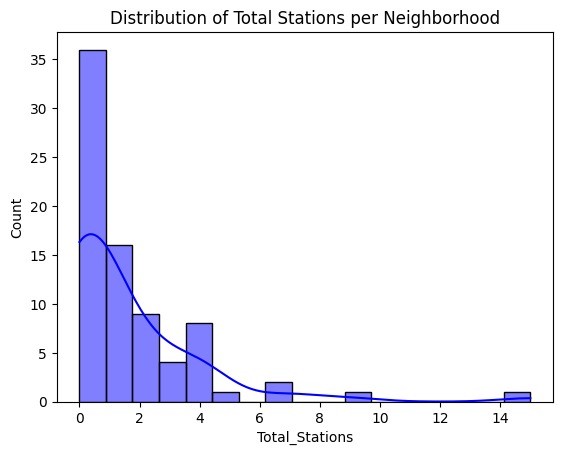

In [ ]:
# Independent Variable: Transit Access
sns.histplot(df['Total_Stations'], kde=True, color='blue')
plt.title('Distribution of Total Stations per Neighborhood')

We see a heavy right-skew in this graph. Nearly half of the 78 neighborhoods do not have a train station.

Text(0.5, 1.0, 'Distribution of Total Daily Rides')

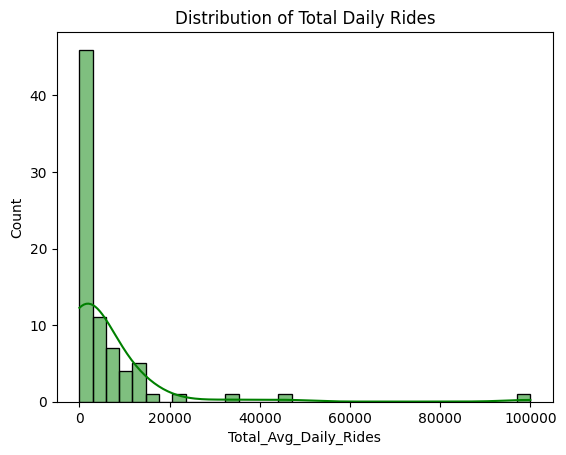

In [ ]:
# Independent Variable Transit Usage
sns.histplot(df['Total_Avg_Daily_Rides'], kde=True, color='green')
plt.title('Distribution of Total Daily Rides')

We see the same skew in this graph which matches up with that of the previous graph. Because the features are heavily right-skewed this can negatively affect a linear model's performance.

**Heat Map**

Text(0.5, 1.0, 'Correlation Matrix')

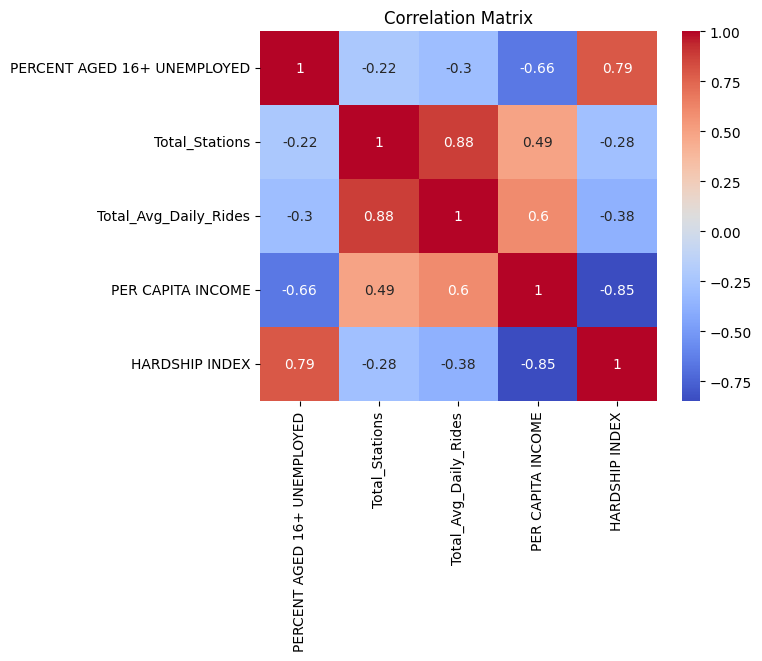

In [ ]:
# Get the relevant features
important_features = ['PERCENT AGED 16+ UNEMPLOYED',
                      'Total_Stations',
                      'Total_Avg_Daily_Rides',
                      'PER CAPITA INCOME',
                      'HARDSHIP INDEX']
# Plot the heat map
corr_matrix = df[important_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

From the heatmap we can see there is a fair to high correlation between all of these features. Between total stations and unemployment we see a -0.22 correlation, and between daily rides and unemployment there is a -0.30 correlation. However, between per capita income, we see correlations of 0.49 and 0.60 respectively, showing that access to train stations may not have as much affect on employment as it does on the type of employment.

We do see high colinearity between Hardship Index and Unemployment as well as Total Stations and Dailt Rides. This makes sense as they measure similar things.

**Bitvariate Analysis**


Text(0, 0.5, 'Unemployment Rate (%)')

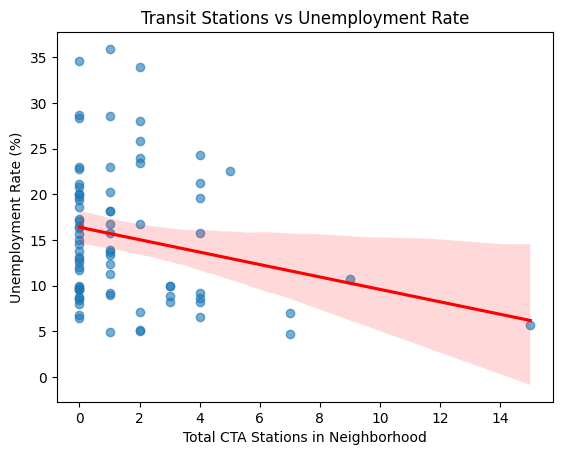

In [ ]:
# Transit Access vs Unemployment
sns.regplot(data=df, x='Total_Stations', y='PERCENT AGED 16+ UNEMPLOYED',
            scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
plt.title('Transit Stations vs Unemployment Rate')
plt.xlabel('Total CTA Stations in Neighborhood')
plt.ylabel('Unemployment Rate (%)')

We see a negative correlation here between Unemployment Rate and Total Stations, however, this does seem to be heavily influenced by the outlier neighborhoods with high amounts of stations.

Text(0, 0.5, 'Unemployment Rate (%)')

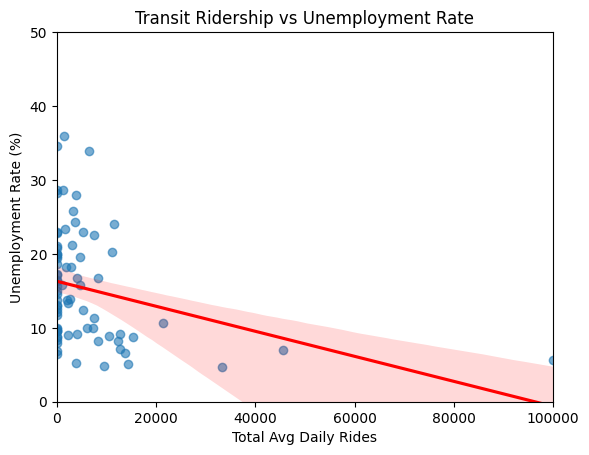

In [ ]:
sns.regplot(data=df, x='Total_Avg_Daily_Rides', y='PERCENT AGED 16+ UNEMPLOYED',
            scatter_kws={'alpha':0.6}, line_kws={"color": "red"})
plt.title('Transit Ridership vs Unemployment Rate')
plt.xlabel('Total Avg Daily Rides')
plt.axis([0, 100000, 0, 50])
plt.ylabel('Unemployment Rate (%)')

This once again follows the same behavior as the previous graph, including the affect by outliers. The majority of the data lies at the left side of the graph, and we see a fair amount of variance there. Some neighborhoods with 0 rides have <10% unemployment, where others have >30%, showing that while transit usage may be a factor, it likely isn't very important.

# Hypothesis Testing

# Model Building


# Knowledge Discovery